# 3.1 距离权重函数

**学习目标**
- 理解雷达体积采样的概念
- 掌握距离权重函数的数学表达式
- 观察脉冲宽度对距离分辨率的影响
- 计算不同权重函数下的有效采样体积

**参考文献**：Ryzhkov & Zrnic, Chapter 3, pp. 231-270

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
plt.rcParams['font.family'] = ['DejaVu Sans', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 1. 理论背景

### 雷达体积采样

雷达发射的脉冲有一定的持续时间 $\tau$，这决定了沿径向的距离分辨率：

$$\Delta r = \frac{c\tau}{2}$$

其中 $c$ 是光速。

### 距离权重函数

对于高斯脉冲形状，距离权重函数为：

$$W(r) = \exp\left(-\frac{4\ln 2 (r-R_0)^2}{\Delta r^2}\right)$$

其中 $R_0$ 是距离库中心，$\Delta r$ 是半功率全宽（FWHM）。

In [2]:
def range_weighting_function(r, R0, delta_r):
    """
    计算高斯形状的距离权重函数
    r: 距离数组
    R0: 距离库中心
    delta_r: FWHM距离分辨率
    """
    return np.exp(-4 * np.log(2) * (r - R0)**2 / delta_r**2)

def rectangular_weighting(r, R0, delta_r):
    """矩形权重函数（简化模型）"""
    return np.where(np.abs(r - R0) <= delta_r/2, 1.0, 0.0)

def effective_beam_width(delta_r, range_dist):
    """
    计算由于距离效应导致的有效波束展宽
    delta_r: 距离分辨率
    range_dist: 到目标的距离
    """
    beam_spread = delta_r / range_dist  # 弧度
    return np.degrees(beam_spread)  # 转换为度

## 2. 距离权重函数可视化

In [3]:
def plot_range_weighting(pulse_width=1.0, center_distance=50.0, beam_width=1.0):
    """绘制距离权重函数"""
    
    # 距离分辨率 (m)
    delta_r = 0.5 * 3e8 * pulse_width * 1e-6  # c * tau / 2
    
    # 距离范围
    r = np.linspace(center_distance - 5*delta_r, center_distance + 5*delta_r, 500)
    
    # 高斯权重
    w_gaussian = range_weighting_function(r, center_distance*1000, delta_r)
    
    # 矩形权重
    w_rect = rectangular_weighting(r, center_distance*1000, delta_r)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 子图1: 权重函数对比
    ax1 = axes[0, 0]
    ax1.plot((r - center_distance*1000)/1000, w_gaussian, 'b-', linewidth=2, label='高斯权重')
    ax1.fill_between((r - center_distance*1000)/1000, w_gaussian, alpha=0.3)
    ax1.plot((r - center_distance*1000)/1000, w_rect, 'r--', linewidth=2, label='矩形权重')
    ax1.axhline(y=0.5, color='gray', linestyle=':', label='半功率线 (0.5)')
    ax1.set_xlabel('距离偏移 (km)', fontsize=11)
    ax1.set_ylabel('权重', fontsize=11)
    ax1.set_title(f'距离权重函数 (Δr={delta_r/1000:.1f}km, τ={pulse_width}μs)', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-3*delta_r/1000, 3*delta_r/1000)
    
    # 子图2: 不同脉冲宽度的权重函数
    ax2 = axes[0, 1]
    pulse_widths = [0.5, 1.0, 2.0]
    colors = ['red', 'green', 'blue']
    for pw, c in zip(pulse_widths, colors):
        dr = 0.5 * 3e8 * pw * 1e-6
        w = range_weighting_function(r, center_distance*1000, dr)
        ax2.plot((r - center_distance*1000)/1000, w, color=c, linewidth=2, 
                label=f'τ={pw}μs (Δr={dr/1000:.1f}km)')
    ax2.set_xlabel('距离偏移 (km)', fontsize=11)
    ax2.set_ylabel('权重', fontsize=11)
    ax2.set_title('不同脉冲宽度的权重函数对比', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 子图3: 有效采样体积示意
    ax3 = axes[1, 0]
    # 波束宽度导致的横向扩展
    theta_3db = np.radians(beam_width)
    range_res = 0.5 * 3e8 * pulse_width * 1e-6
    
    # 采样椭圆的长轴和短轴
    a = range_res  # 径向
    b = center_distance*1000 * np.tan(theta_3db/2)  # 横向
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = a * np.cos(theta)
    y = b * np.sin(theta)
    
    ax3.fill(x/1000, y/1000, alpha=0.3, color='blue')
    ax3.plot(x/1000, y/1000, 'b-', linewidth=2)
    ax3.set_xlabel('径向距离 (km)', fontsize=11)
    ax3.set_ylabel('横向距离 (km)', fontsize=11)
    ax3.set_title(f'有效采样体积示意 (波束宽度{beam_width}°)', fontsize=11)
    ax3.set_aspect('equal')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(-max(a,b)/1000*1.2, max(a,b)/1000*1.2)
    ax3.set_ylim(-max(a,b)/1000*1.2, max(a,b)/1000*1.2)
    
    # 子图4: 权重函数积分与有效宽度
    ax4 = axes[1, 1]
    ranges = np.linspace(10, 200, 100)  # km
    effective_width = [effective_beam_width(delta_r, r*1000) for r in ranges]
    ax4.plot(ranges, effective_width, 'g-', linewidth=2)
    ax4.set_xlabel('距离 (km)', fontsize=11)
    ax4.set_ylabel('角度扩展 (°)', fontsize=11)
    ax4.set_title('有效波束展宽随距离的变化', fontsize=11)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== 距离分辨率参数 ===")
    print(f"脉冲宽度: {pulse_width} μs")
    print(f"距离分辨率 Δr: {delta_r/1000:.2f} km")
    print(f"采样体积 (径向): {delta_r/1000:.2f} km")
    print(f"采样体积 (横向 @{center_distance}km): ±{b/1000:.2f} km")
    print(f"有效采样体积: ~{np.pi*a*b/1e6:.2f} km³")

In [4]:
interact_rw = interact(plot_range_weighting,
    pulse_width=widgets.FloatSlider(min=0.1, max=4.0, step=0.1, value=1.0, 
                                  description='脉冲宽度 (μs)'),
    center_distance=widgets.FloatSlider(min=10, max=200, step=10, value=50.0, 
                                        description='距离 (km)'),
    beam_width=widgets.FloatSlider(min=0.5, max=2.0, step=0.1, value=1.0, 
                                  description='波束宽度 (°)')
)

interactive(children=(FloatSlider(value=1.0, description='脉冲宽度 (μs)', max=4.0, min=0.1), FloatSlider(value=50.…

## 3. 不同权重函数对比

In [5]:
def compare_weighting_functions():
    """对比不同权重函数的特点"""
    pulse_width = 1.0
    delta_r = 0.5 * 3e8 * pulse_width * 1e-6
    R0 = 50.0 * 1000  # m
    
    r = np.linspace(R0 - 3*delta_r, R0 + 3*delta_r, 500)
    
    # 高斯权重
    w_gaussian = range_weighting_function(r, R0, delta_r)
    
    # sinc权重 (实际雷达脉冲形状)
    w_sinc = np.sinc((r - R0) / (delta_r / (2*np.sqrt(np.log(2)))) )**2
    w_sinc = w_sinc / w_sinc.max()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot((r-R0)/1000, w_gaussian, 'b-', linewidth=2, label='高斯权重 (近似)')
    ax.plot((r-R0)/1000, w_sinc, 'r--', linewidth=2, label='sinc权重 (实际脉冲)')
    ax.fill_between((r-R0)/1000, w_gaussian, alpha=0.2)
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('距离偏移 (km)', fontsize=12)
    ax.set_ylabel('权重', fontsize=12)
    ax.set_title(f'权重函数对比 (Δr={delta_r/1000:.1f}km)', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1.5, 1.5)
    
    plt.tight_layout()
    plt.show()
    
    # 计算有效宽度
    integral_g = np.trapezoid(w_gaussian, r)
    integral_s = np.trapezoid(w_sinc, r)
    fwhm_g = 2 * np.sqrt(2 * np.log(2)) * delta_r / np.sqrt(4 * np.log(2))  # 简化
    fwhm_s = delta_r  # sinc的主瓣宽度
    
    print(f"\n=== 权重函数对比 ===")
    print(f"高斯权重 FWHM: ~{delta_r/1000:.2f} km")
    print(f"sinc权重 主瓣宽度: ~{delta_r/1000:.2f} km")
    print(f"高斯权重积分: {integral_g:.2e}")
    print(f"sinc权重积分: {integral_s:.2e}")

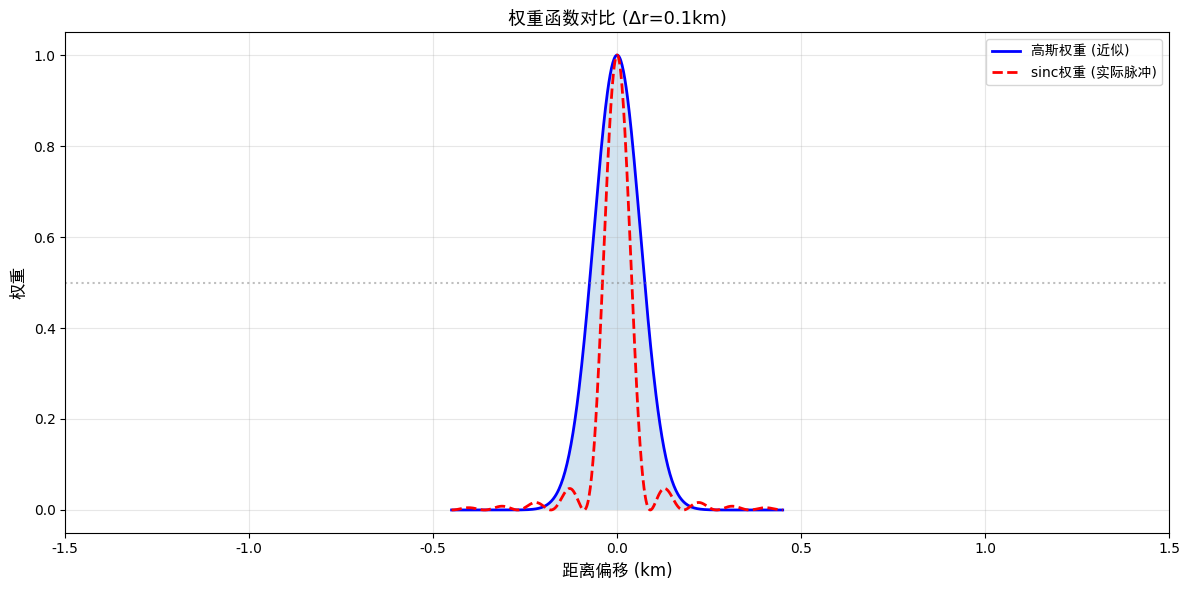


=== 权重函数对比 ===
高斯权重 FWHM: ~0.15 km
sinc权重 主瓣宽度: ~0.15 km
高斯权重积分: 1.60e+02
sinc权重积分: 8.83e+01


In [6]:
compare_weighting_functions()

## 练习题

1. **分辨率计算**：脉冲宽度为2μs时，距离分辨率是多少？

2. **权重函数形状**：高斯权重函数和矩形权重函数各有何优缺点？

3. **采样体积变化**：随着距离增加，采样体积如何变化？为什么远距离的雷达数据空间分辨率较低？

4. **波束展宽**：S波段雷达波束宽度1°，在100km处的横向采样宽度是多少？

## 参考文献

- Ryzhkov, A.V., and D.S. Zrnic, 2019: *Radar Polarimetry for Weather Observations*, Chapter 3, Springer.